# LightGBM — Baseline
Treino em 2020–2023, teste em 2024. Sem SMOTE — desbalanceamento tratado via `class_weight='balanced'`.
LightGBM lida com NaN nativamente; ALRM_*/GRAV_* preenchidos com 0 (ausência informativa).
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR     = '../../data/features/baseline'
OUTPUT_MOD   = '../../output/modelos'
OUTPUT_MET   = '../../output/metricas'
ALGO         = 'lightgbm'
DATASET      = 'baseline'
RANDOM_STATE = 42
YEAR_COL     = 'year'

## 1. Carregamento dos dados

In [2]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

# Remove NaN do target
mask    = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

print(f'X_train: {X_train.shape} | Óbitos: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | Óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')

X_train: (137743, 52) | Óbitos: 2,640 (1.92%)
X_test:  (160534, 52)  | Óbitos: 5,295 (3.30%)


## 2. Pipeline

In [3]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]

# LightGBM não precisa de scaling nem imputation para colunas numéricas —
# lida com NaN nativamente. Apenas encodamos strings e preenchemos ALRM_*/GRAV_*.
preprocessor = ColumnTransformer(
    transformers=[
        # Ausência informativa: NaN → 0
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        # CS_SEXO: F→0 / M→1 / desconhecido→-1
        ('sexo',
         OrdinalEncoder(categories=[['F', 'M']],
                        handle_unknown='use_encoded_value',
                        unknown_value=-1),
         ['CS_SEXO']),

        # SG_UF: encode ordinal
        ('uf',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['SG_UF']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=20,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )),
])

print('Pipeline definido.')

Pipeline definido.


## 3. Treinamento

In [4]:
def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_train_prep = prep_X(X_train)
X_test_prep  = prep_X(X_test)

pipeline.fit(X_train_prep, y_train)
print('Treinamento concluído.')

Treinamento concluído.


## 4. Avaliação

=== LightGBM — Baseline (2020–2023 → 2024) ===
  sensibilidade: 0.682
  especificidade: 0.952
  auprc: 0.6098
  roc_auc: 0.9024
  f1: 0.4415
  precisao: 0.3264
  threshold: 0.5
  n_train: 137743
  n_obito_train: 2640

              precision    recall  f1-score   support

        Cura       0.99      0.95      0.97    155239
       Óbito       0.33      0.68      0.44      5295

    accuracy                           0.94    160534
   macro avg       0.66      0.82      0.71    160534
weighted avg       0.97      0.94      0.95    160534



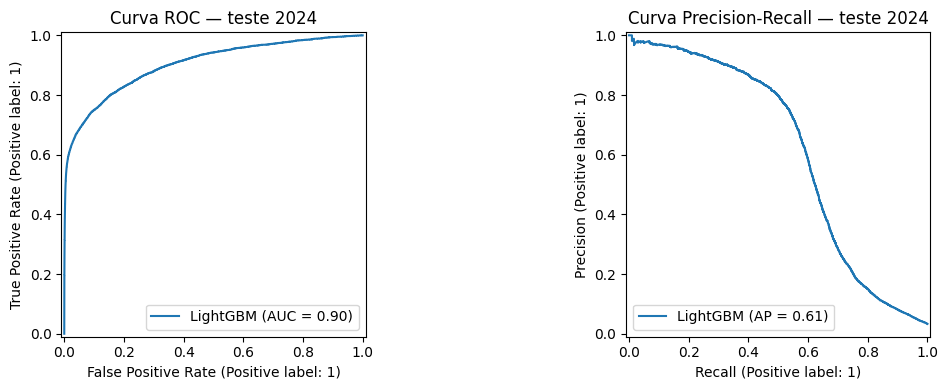

In [5]:
y_te    = y_test.dropna()
proba   = pipeline.predict_proba(X_test_prep)[:, 1]
proba   = proba[y_test.notna().values]

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        len(X_train_prep),
        'n_obito_train':  int(y_train.sum()),
    }

metricas = calcular_metricas(y_te, proba)
print('=== LightGBM — Baseline (2020–2023 → 2024) ===')
for k, v in metricas.items():
    print(f'  {k}: {v}')

print()
print(classification_report(y_te, (proba >= 0.5).astype(int), target_names=['Cura', 'Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[0], name='LightGBM')
axes[0].set_title('Curva ROC — teste 2024')
PrecisionRecallDisplay.from_predictions(y_te, proba, ax=axes[1], name='LightGBM')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

## 5. Matriz de Confusão (threshold = 0.5)

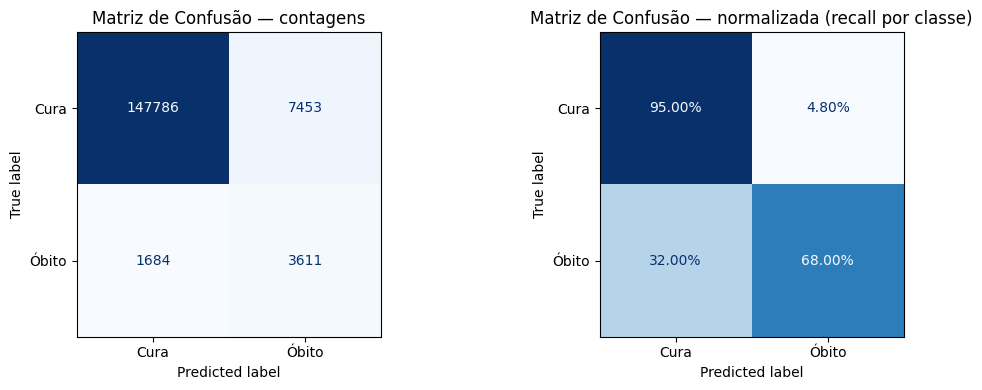

VP (óbitos detectados):   3,611
FN (óbitos perdidos):     1,684
FP (falsos alarmes):      7,453
VN (curas classificadas): 147,786


In [6]:
y_pred_05 = (proba >= 0.5).astype(int)
cm        = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 6. Análise de threshold

Threshold padrão  (0.50): sens=0.6820 | esp=0.9520
Threshold Youden  (0.35): sens=0.7388 | esp=0.9118
Threshold sens≥90% (0.05): sens=0.9226 | esp=0.5819


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9226,0.5819,0.0700,0.1301,4885,64903,410,90336
1,0.10,0.8750,0.7104,0.0934,0.1688,4633,44950,662,110289
2,0.15,0.8383,0.7807,0.1153,0.2028,4439,34045,856,121194
3,0.20,0.8087,0.8302,0.1398,0.2383,4282,26356,1013,128883
4,0.25,0.7813,0.8649,0.1648,0.2721,4137,20972,1158,134267
5,0.30,0.7556,0.8914,0.1918,0.3060,4001,16857,1294,138382
6,0.35,0.7388,0.9118,0.2223,0.3417,3912,13688,1383,141551
7,0.40,0.7165,0.9281,0.2537,0.3747,3794,11161,1501,144078
8,0.45,0.6986,0.9411,0.2881,0.4079,3699,9141,1596,146098
9,0.50,0.6820,0.9520,0.3264,0.4415,3611,7453,1684,147786


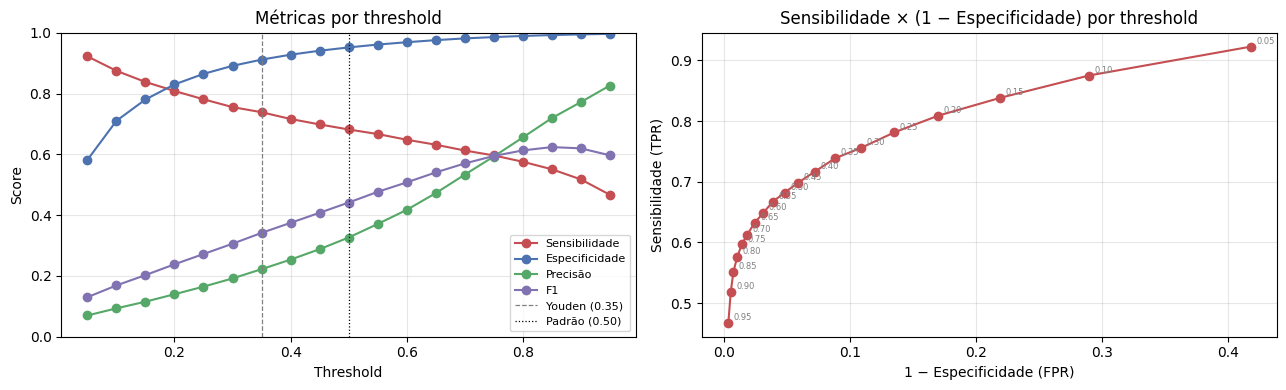

In [7]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90    = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sens={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} "
      f"| esp={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): "
      f"sens={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): "
          f"sens={df_thresh.loc[idx_90,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--',
                linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 − Especificidade) por threshold')
axes[1].set_xlabel('1 − Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Importância das features

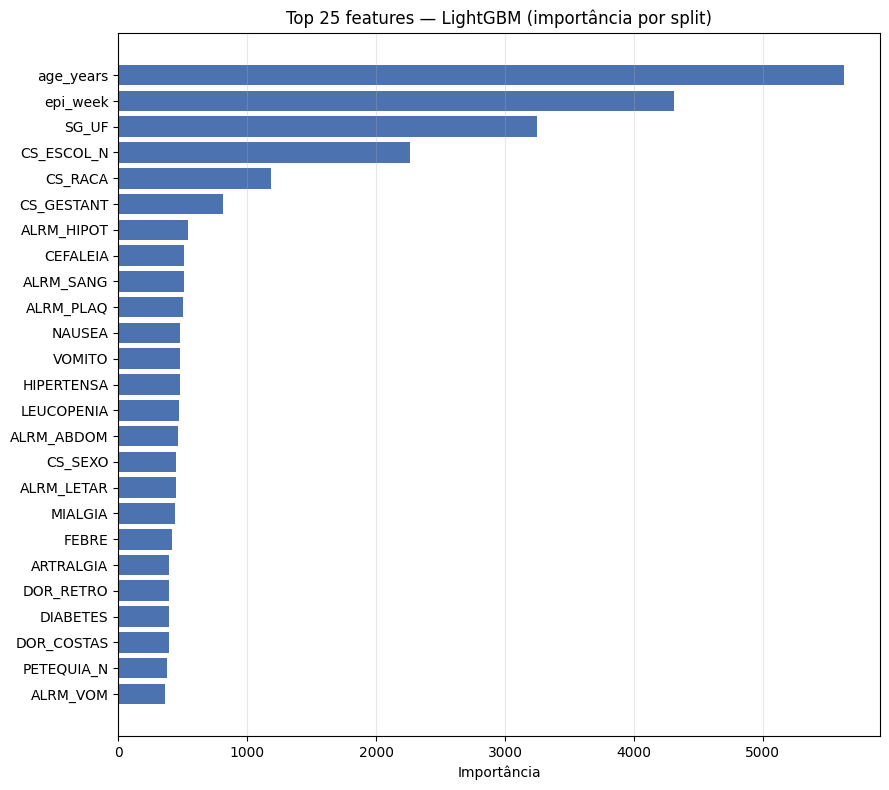

,feature,importance
49,age_years,5629
50,epi_week,4312
25,SG_UF,3248
28,CS_ESCOL_N,2266
27,CS_RACA,1188
26,CS_GESTANT,814
0,ALRM_HIPOT,539
31,CEFALEIA,512
3,ALRM_SANG,506
1,ALRM_PLAQ,504


In [8]:
feature_names = pipeline['pre'].get_feature_names_out()
importances   = pipeline['clf'].feature_importances_

df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_n = 25
df_top = df_imp.head(top_n)
ax.barh(df_top['feature'][::-1], df_top['importance'][::-1], color='#4C72B0')
ax.set_title(f'Top {top_n} features — LightGBM (importância por split)')
ax.set_xlabel('Importância')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(df_imp.head(15))

## 8. Salvamento

In [9]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline, model_path)
print(f'Modelo salvo: {model_path}')

df_met = pd.DataFrame([metricas])
df_met['label']   = f'{ALGO}_{DATASET}'
df_met['dataset'] = DATASET
met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_met.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/lightgbm_baseline.joblib
Métricas salvas: ../../output/metricas/lightgbm_baseline.parquet
Predições salvas: ../../output/metricas/lightgbm_baseline_predicoes.parquet


## 9. Otimização de Hiperparâmetros (GridSearchCV)
Busca exaustiva sobre `num_leaves`, `min_child_samples` e `learning_rate`. `n_estimators` fixo em 500.
Avaliação por `StratifiedKFold(5)` dentro do train set (2020–2023). Scoring: `average_precision` (AUPRC).

Total: 3 × 3 × 3 = 27 combinações × 5 folds = 135 fits.

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', LGBMClassifier(
            n_estimators=500,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )),
    ])

param_grid = {
    'clf__num_leaves':        [31, 63, 127],
    'clf__min_child_samples': [10, 20, 50],
    'clf__learning_rate':     [0.01, 0.05, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=build_pipeline(),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_prep, y_train)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUPRC (CV):   {grid_search.best_score_:.4f}')

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv = df_cv[['param_clf__num_leaves', 'param_clf__min_child_samples', 'param_clf__learning_rate',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
df_cv = df_cv.sort_values('rank_test_score')
display(df_cv)

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Melhores parâmetros: {'clf__learning_rate': 0.05, 'clf__min_child_samples': 50, 'clf__num_leaves': 31}
Melhor AUPRC (CV):   0.6479


,param_clf__num_leaves,param_clf__min_child_samples,param_clf__learning_rate,mean_test_score,std_test_score,rank_test_score
15,31,50,0.05,0.647892,0.017162,1
7,63,50,0.01,0.646687,0.016797,2
6,31,50,0.01,0.645747,0.021553,3
1,63,10,0.01,0.645599,0.016367,4
3,31,20,0.01,0.645174,0.020098,5
0,31,10,0.01,0.645130,0.020454,6
16,63,50,0.05,0.644488,0.016578,7
4,63,20,0.01,0.644293,0.018703,8
12,31,20,0.05,0.642935,0.015462,9
8,127,50,0.01,0.642413,0.016241,10


## 10. Avaliação — Modelo Tunado

=== Comparação: Baseline vs Tunado ===
Métrica              Baseline     Tunado
----------------------------------------
sensibilidade          0.6820     0.7549  (+0.0729)
especificidade         0.9520     0.9201  (-0.0319)
auprc                  0.6098     0.6294  (+0.0196)
roc_auc                0.9024     0.9136  (+0.0112)
f1                     0.4415     0.3685  (-0.0730)


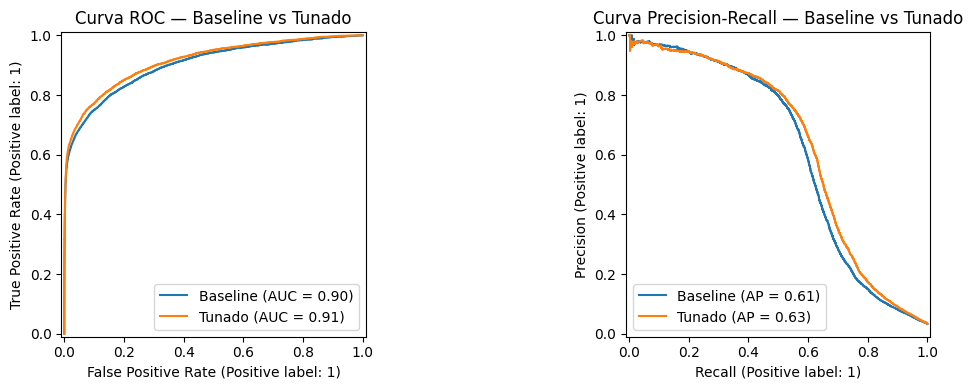

In [11]:
pipeline_tuned = grid_search.best_estimator_

proba_tuned = pipeline_tuned.predict_proba(X_test_prep)[:, 1]
proba_tuned = proba_tuned[y_test.notna().values]

metricas_tuned = calcular_metricas(y_te, proba_tuned)

print('=== Comparação: Baseline vs Tunado ===')
print(f"{'Métrica':<18} {'Baseline':>10} {'Tunado':>10}")
print('-' * 40)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_base  = metricas[k]
    v_tuned = metricas_tuned[k]
    diff    = v_tuned - v_base
    sinal   = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_base:>10.4f} {v_tuned:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba,       ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_te, proba_tuned, ax=axes[0], name='Tunado')
axes[0].set_title('Curva ROC — Baseline vs Tunado')

PrecisionRecallDisplay.from_predictions(y_te, proba,       ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_te, proba_tuned, ax=axes[1], name='Tunado')
axes[1].set_title('Curva Precision-Recall — Baseline vs Tunado')
plt.tight_layout()
plt.show()

## 11. Salvamento — Modelo Tunado

In [12]:
DATASET_TUNED = f'{DATASET}_tuned'

model_path_tuned = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET_TUNED}.joblib')
joblib.dump(pipeline_tuned, model_path_tuned)
print(f'Modelo salvo: {model_path_tuned}')

df_met_tuned = pd.DataFrame([metricas_tuned])
df_met_tuned['label']       = f'{ALGO}_{DATASET_TUNED}'
df_met_tuned['dataset']     = DATASET_TUNED
df_met_tuned['best_params'] = str(grid_search.best_params_)
met_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}.parquet')
df_met_tuned.to_parquet(met_path_tuned, index=False)
print(f'Métricas salvas: {met_path_tuned}')

df_pred_tuned = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_tuned})
pred_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}_predicoes.parquet')
df_pred_tuned.to_parquet(pred_path_tuned, index=False)
print(f'Predições salvas: {pred_path_tuned}')

Modelo salvo: ../../output/modelos/lightgbm_baseline_tuned.joblib
Métricas salvas: ../../output/metricas/lightgbm_baseline_tuned.parquet
Predições salvas: ../../output/metricas/lightgbm_baseline_tuned_predicoes.parquet


## 12. Conclusão

O LightGBM **não superou** a regressão logística nas métricas prioritárias do projeto.

| Modelo               | Sensibilidade | Especificidade | AUPRC  | ROC-AUC |
|----------------------|--------------|----------------|--------|---------|
| Logística (baseline) | **0.8004**   | 0.8853         | **0.6250** | **0.9242** |
| LightGBM (baseline)  | 0.6820       | 0.9520         | 0.6098 | 0.9024  |

**Observações:**
- O LightGBM privilegia especificidade em detrimento de sensibilidade — inverso do objetivo clínico.
- AUPRC e ROC-AUC inferiores à regressão logística indicam menor capacidade discriminativa geral.
- Ajuste de threshold não resolve o problema: atingir sensibilidade equivalente à LR exige threshold=0.20, gerando ~26k falsos alarmes contra ~7k da logística.

**Modelo selecionado até o momento:** `logistic_regression_baseline`.